# Haxby Visual Reconstruction


In [ ]:
# Haxby Visual Reconstruction

In [1]:
!pip install nilearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 116.5 MB/s eta 0:00:00


In [2]:
!unzip multi_subject.zip -d /content/

Archive:  multi_subject.zip
   creating: /content/multi_subject/
  inflating: /content/multi_subject/subject_3_labels.npy  
  inflating: /content/multi_subject/subject_3_fmri.npy  
  inflating: /content/multi_subject/reconstruction_house.png  
  inflating: /content/multi_subject/subject_5_labels.npy  
  inflating: /content/multi_subject/diffusion_prior_final.pth  
  inflating: /content/multi_subject/category_metrics.csv  
  inflating: /content/multi_subject/reconstruction_chair.png  
  inflating: /content/multi_subject/reconstruction_face.png  
  inflating: /content/multi_subject/val_labels.npy  
  inflating: /content/multi_subject/subject_1_labels.npy  
  inflating: /content/multi_subject/reconstruction_scissors.png  
  inflating: /content/multi_subject/reconstruction_bottle.png  
  inflating: /content/multi_subject/train_labels.npy  
  inflating: /content/multi_subject/train_aligned.npy  
  inflating: /content/multi_subject/transformer_best.pth  
  inflating: /content/multi_subject/v

In [ ]:
# =========================================================
# METHOD 3
# PART 1/3
# MODEL + DATA LOADING (FINAL)
# =========================================================

!pip install open_clip_torch diffusers transformers timm -q

import os
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import open_clip

from PIL import Image
from torchvision import transforms
from nilearn import datasets
from fmri_reconstruction.reconstruction.stable_diffusion import StableDiffusionImg2Img

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float16 if DEVICE == "cuda" else torch.float32

print("Using device:", DEVICE)

# =========================================================
# CONFIG
# =========================================================
INPUT_DIM = 128
LATENT_DIM = 256
SEQ_LEN = 20

CLIP_WEIGHT = 0.35
DINO_WEIGHT = 0.65

# =========================================================
# LOAD TEST DATA
# =========================================================
X = np.load("multi_subject/test_aligned.npy")
labels = np.load("multi_subject/test_labels.npy")

print("Data shape:", X.shape)

# =========================================================
# LABEL NORMALIZATION
# =========================================================
def normalize_label(lbl):
    lbl = str(lbl).lower().strip()
    mapping = {
        "faces": "face",
        "houses": "house",
        "cats": "cat",
        "bottles": "bottle",
        "chairs": "chair",
        "shoes": "shoe"
    }
    return mapping.get(lbl, lbl)

labels = np.array([normalize_label(x) for x in labels])

# =========================================================
# LOAD STIMULI
# =========================================================
haxby = datasets.fetch_haxby(subjects=[1], fetch_stimuli=True)
stimuli = haxby.stimuli

category_images = {
    "face": stimuli["faces"],
    "house": stimuli["houses"],
    "cat": stimuli["cats"],
    "bottle": stimuli["bottles"],
    "chair": stimuli["chairs"],
    "scissors": stimuli["scissors"],
    "shoe": stimuli["shoes"]
}

print("Stimuli loaded")

# =========================================================
# BUILD TEST IMAGE PATHS
# =========================================================
img_paths = []
category_idx = {k: 0 for k in category_images}

for lbl in labels:
    if lbl in category_images:
        idx = category_idx[lbl]
        img_paths.append(category_images[lbl][idx % len(category_images[lbl])])
        category_idx[lbl] += 1
    else:
        img_paths.append(None)

print("Stimulus paths built")

# =========================================================
# POSITIONAL ENCODING
# =========================================================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2) *
            (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

# =========================================================
# FMRI TRANSFORMER
# =========================================================
class FMRITransformer(nn.Module):
    def __init__(self):
        super().__init__()

        self.embedding = nn.Linear(INPUT_DIM, LATENT_DIM)
        self.pos = PositionalEncoding(LATENT_DIM)

        self.cls = nn.Parameter(torch.randn(1, 1, LATENT_DIM))

        layer = nn.TransformerEncoderLayer(
            d_model=LATENT_DIM,
            nhead=8,
            dim_feedforward=512,
            dropout=0.1,
            activation="gelu",
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(layer, num_layers=4)

        self.attention_pool = nn.Sequential(
            nn.Linear(LATENT_DIM, 128),
            nn.Tanh(),
            nn.Linear(128, 1)
        )

        self.norm = nn.LayerNorm(LATENT_DIM)

        self.head = nn.Sequential(
            nn.Linear(LATENT_DIM, 512),
            nn.GELU(),
            nn.Linear(512, INPUT_DIM)
        )

    def forward(self, x):
        B = x.shape[0]

        x = self.embedding(x)
        cls = self.cls.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = self.pos(x)
        x = self.transformer(x)

        attn = torch.softmax(self.attention_pool(x), dim=1)
        pooled = (x * attn).sum(dim=1)

        latent = self.norm(pooled)
        recon = self.head(latent)

        return latent, recon

# =========================================================
# PROJECTORS
# =========================================================
class FMRIToCLIP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(256, 1024),
            nn.LayerNorm(1024),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(1024, 1024),
            nn.LayerNorm(1024),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(1024, 512)
        )
    def forward(self, x):
        return self.net(x)

class FMRIToDINO(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(256, 1024),
            nn.LayerNorm(1024),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(1024, 768)
        )
    def forward(self, x):
        return self.net(x)

class DiffusionPrior(nn.Module):
    def __init__(self):
        super().__init__()

        self.time_embed = nn.Sequential(
            nn.Linear(1, 512),
            nn.GELU(),
            nn.Linear(512, 512)
        )

        self.net = nn.Sequential(
            nn.Linear(1024, 2048),
            nn.LayerNorm(2048),
            nn.GELU(),
            nn.Linear(2048, 512)
        )

    def forward(self, x, t):
        t_embed = self.time_embed(t)
        x = torch.cat([x, t_embed], dim=-1)
        return self.net(x)

# =========================================================
# LOAD MODELS
# =========================================================
fmri_model = FMRITransformer().to(DEVICE)
clip_projector = FMRIToCLIP().to(DEVICE)
dino_projector = FMRIToDINO().to(DEVICE)
prior = DiffusionPrior().to(DEVICE)

fmri_model.load_state_dict(torch.load("multi_subject/transformer_best.pth", map_location=DEVICE))
clip_projector.load_state_dict(torch.load("multi_subject/clip_projector_best.pth", map_location=DEVICE))
dino_projector.load_state_dict(torch.load("multi_subject/dino_projector_best.pth", map_location=DEVICE))
prior.load_state_dict(torch.load("multi_subject/diffusion_prior_best.pth", map_location=DEVICE))

fmri_model.eval()
clip_projector.eval()
dino_projector.eval()
prior.eval()

print("Neural models loaded")

# =========================================================
# LOAD CLIP
# =========================================================
clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32",
    pretrained="laion2b_s34b_b79k"
)
clip_model = clip_model.to(DEVICE).float().eval()

# =========================================================
# DINO PREPROCESS
# =========================================================
dino_preprocess = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.485,0.456,0.406),
        std=(0.229,0.224,0.225)
    )
])

# =========================================================
# LOAD DINO
# IMPORTANT: CLS TOKEN SPACE
# =========================================================
dinov2 = torch.hub.load(
    "facebookresearch/dinov2",
    "dinov2_vitb14"
)
dinov2 = dinov2.to(DEVICE).eval()

print("PART 1 COMPLETE")

Using device: cuda
Data shape: (864, 128)


[fetch_haxby] Dataset found in /root/nilearn_data/haxby2001

Stimuli loaded
Stimulus paths built
Neural models loaded


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


PART 1 COMPLETE


In [ ]:
# =========================================================
# METHOD 3
# PART 2/3
# RETRIEVAL DATABASE + DIFFUSION
# FINAL (MATCHES PART 1 & PART 3)
# NO LEAKAGE VERSION
# =========================================================

from diffusers import StableDiffusionImg2ImgPipeline
import torch
import torch.nn.functional as F
from PIL import Image
import numpy as np

# =========================================================
# LOAD STABLE DIFFUSION
# =========================================================
pipe = StableDiffusionImg2Img(
    model_id="runwayml/stable-diffusion-v1-5",
    device=DEVICE,
    torch_dtype=DTYPE,
    disable_safety=True,
    enable_xformers=False,
)

print("✅ Stable Diffusion loaded")

# =========================================================
# LOAD TRAIN LABELS ONLY (NO LEAKAGE)
# =========================================================
train_labels = np.load(
    "multi_subject/train_labels.npy"
)

train_labels = np.array([
    normalize_label(x)
    for x in train_labels
])

print("Train labels:", len(train_labels))

# =========================================================
# BUILD TRAIN IMAGE PATHS
# =========================================================
train_img_paths = []
train_category_idx = {
    k: 0 for k in category_images
}

for lbl in train_labels:
    if lbl in category_images:
        idx = train_category_idx[lbl]

        train_img_paths.append(
            category_images[lbl][
                idx % len(category_images[lbl])
            ]
        )

        train_category_idx[lbl] += 1
    else:
        train_img_paths.append(None)

print("✅ Train stimulus paths built")

# =========================================================
# BUILD DATABASE
# =========================================================
database = {}

for cat in category_images.keys():
    database[cat] = {
        "clip": [],
        "dino": [],
        "images": []
    }

seen = set()

print("\n🔍 Building retrieval database from TRAIN...")

for idx, path in enumerate(train_img_paths):

    if path is None:
        continue

    label = train_labels[idx]

    if label not in category_images:
        continue

    key = (path, label)

    if key in seen:
        continue

    seen.add(key)

    if idx % 100 == 0:
        print(f"Processing {idx}/{len(train_img_paths)}")

    img = Image.open(path).convert("RGB")

    clip_tensor = clip_preprocess(
        img
    ).unsqueeze(0).to(DEVICE)

    dino_tensor = dino_preprocess(
        img
    ).unsqueeze(0).to(DEVICE)

    with torch.no_grad():

        # CLIP embedding
        clip_emb = clip_model.encode_image(
            clip_tensor
        ).float()

        clip_emb = F.normalize(
            clip_emb,
            dim=-1
        )

        # DINO embedding (CLS TOKEN)
        try:
            features = dinov2.forward_features(
                dino_tensor
            )
            dino_emb = features[
                "x_norm_clstoken"
            ]
        except:
            dino_emb = dinov2(
                dino_tensor
            )

        dino_emb = F.normalize(
            dino_emb,
            dim=-1
        )

    database[label]["clip"].append(
        clip_emb.squeeze(0).cpu()
    )

    database[label]["dino"].append(
        dino_emb.squeeze(0).cpu()
    )

    database[label]["images"].append(path)

# =========================================================
# CONVERT DATABASE TO TENSORS
# =========================================================
for cat in database.keys():

    if len(database[cat]["images"]) == 0:
        continue

    database[cat]["clip"] = torch.stack(
        database[cat]["clip"]
    ).to(DEVICE)

    database[cat]["dino"] = torch.stack(
        database[cat]["dino"]
    ).to(DEVICE)

    print(
        f"{cat}: {len(database[cat]['images'])} images"
    )

print("✅ Retrieval database ready")

# =========================================================
# PROMPT FUNCTION
# =========================================================
def get_prompt(label):

    prompts = {
        "face": "high quality grayscale realistic human face",
        "house": "high quality grayscale realistic house",
        "cat": "high quality grayscale realistic cat",
        "bottle": "high quality grayscale realistic bottle",
        "chair": "high quality grayscale realistic chair",
        "scissors": "high quality grayscale realistic scissors",
        "shoe": "high quality grayscale realistic shoe"
    }

    return prompts.get(
        label,
        "high quality grayscale object"
    )

# =========================================================
# RETRIEVAL FUNCTION
# RETURNS EXACTLY 4 VALUES FOR PART 3
# =========================================================
def retrieve_best_image(
    pred_clip,
    pred_dino,
    current_label
):

    db = database[current_label]

    clip_db = db["clip"]
    dino_db = db["dino"]
    images = db["images"]

    with torch.no_grad():

        clip_sim = pred_clip @ clip_db.T
        dino_sim = pred_dino @ dino_db.T

        # DINO weighted more for shape
        if current_label in [
            "chair",
            "bottle",
            "scissors"
        ]:
            fusion = (
                0.15 * clip_sim +
                0.85 * dino_sim
            )
        else:
            fusion = (
                0.30 * clip_sim +
                0.70 * dino_sim
            )

        best_idx = fusion.argmax().item()

        clip_score = clip_sim[
            0, best_idx
        ].item()

        dino_score = dino_sim[
            0, best_idx
        ].item()

        fusion_score = fusion[
            0, best_idx
        ].item()

    return (
        images[best_idx],
        clip_score,
        dino_score,
        fusion_score
    )

# =========================================================
# DIFFUSION SETTINGS
# =========================================================
def get_adaptive_strength(similarity):

    if similarity > 0.92:
        return 0.08
    elif similarity > 0.85:
        return 0.12
    elif similarity > 0.75:
        return 0.16
    else:
        return 0.22


def get_adaptive_guidance(clip_score):

    if clip_score > 0.90:
        return 4.5
    elif clip_score > 0.80:
        return 5.5
    elif clip_score > 0.70:
        return 6.5
    else:
        return 8.0

print("\n✅ METHOD 3 PART 2 COMPLETE")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

✅ Stable Diffusion loaded
Train labels: 3456
✅ Train stimulus paths built

🔍 Building retrieval database from TRAIN...
Processing 0/3456
Processing 100/3456
Processing 200/3456
Processing 300/3456
face: 48 images
house: 48 images
cat: 48 images
bottle: 48 images
chair: 48 images
scissors: 48 images
shoe: 47 images
✅ Retrieval database ready

✅ METHOD 3 PART 2 COMPLETE



🚀 Generating improved reconstructions...

Processing category: scissors
CLIP score : 0.7328
DINO score : 0.3852
Fusion     : 0.5912
Strength : 0.24
Guidance : 7.0


  0%|          | 0/24 [00:00<?, ?it/s]

Saved: multi_subject/reconstruction_scissors.png

Processing category: shoe
CLIP score : 0.6423
DINO score : 0.4198
Fusion     : 0.6717
Strength : 0.18
Guidance : 8.5


  0%|          | 0/18 [00:00<?, ?it/s]

Saved: multi_subject/reconstruction_shoe.png

Processing category: house
CLIP score : 0.6941
DINO score : 0.3275
Fusion     : 0.6576
Strength : 0.18
Guidance : 7.0


...

Saved: multi_subject/reconstruction_bottle.png

Processing category: face
CLIP score : 0.6477
DINO score : 0.4547
Fusion     : 0.6018
Strength : 0.24
Guidance : 8.5


  0%|          | 0/24 [00:00<?, ?it/s]

Saved: multi_subject/reconstruction_face.png

Processing category: chair
CLIP score : 0.7071
DINO score : 0.4200
Fusion     : 0.4631
Strength : 0.08
Guidance : 4.5


  0%|          | 0/8 [00:00<?, ?it/s]

Saved: multi_subject/reconstruction_chair.png

✅ All reconstructions completed


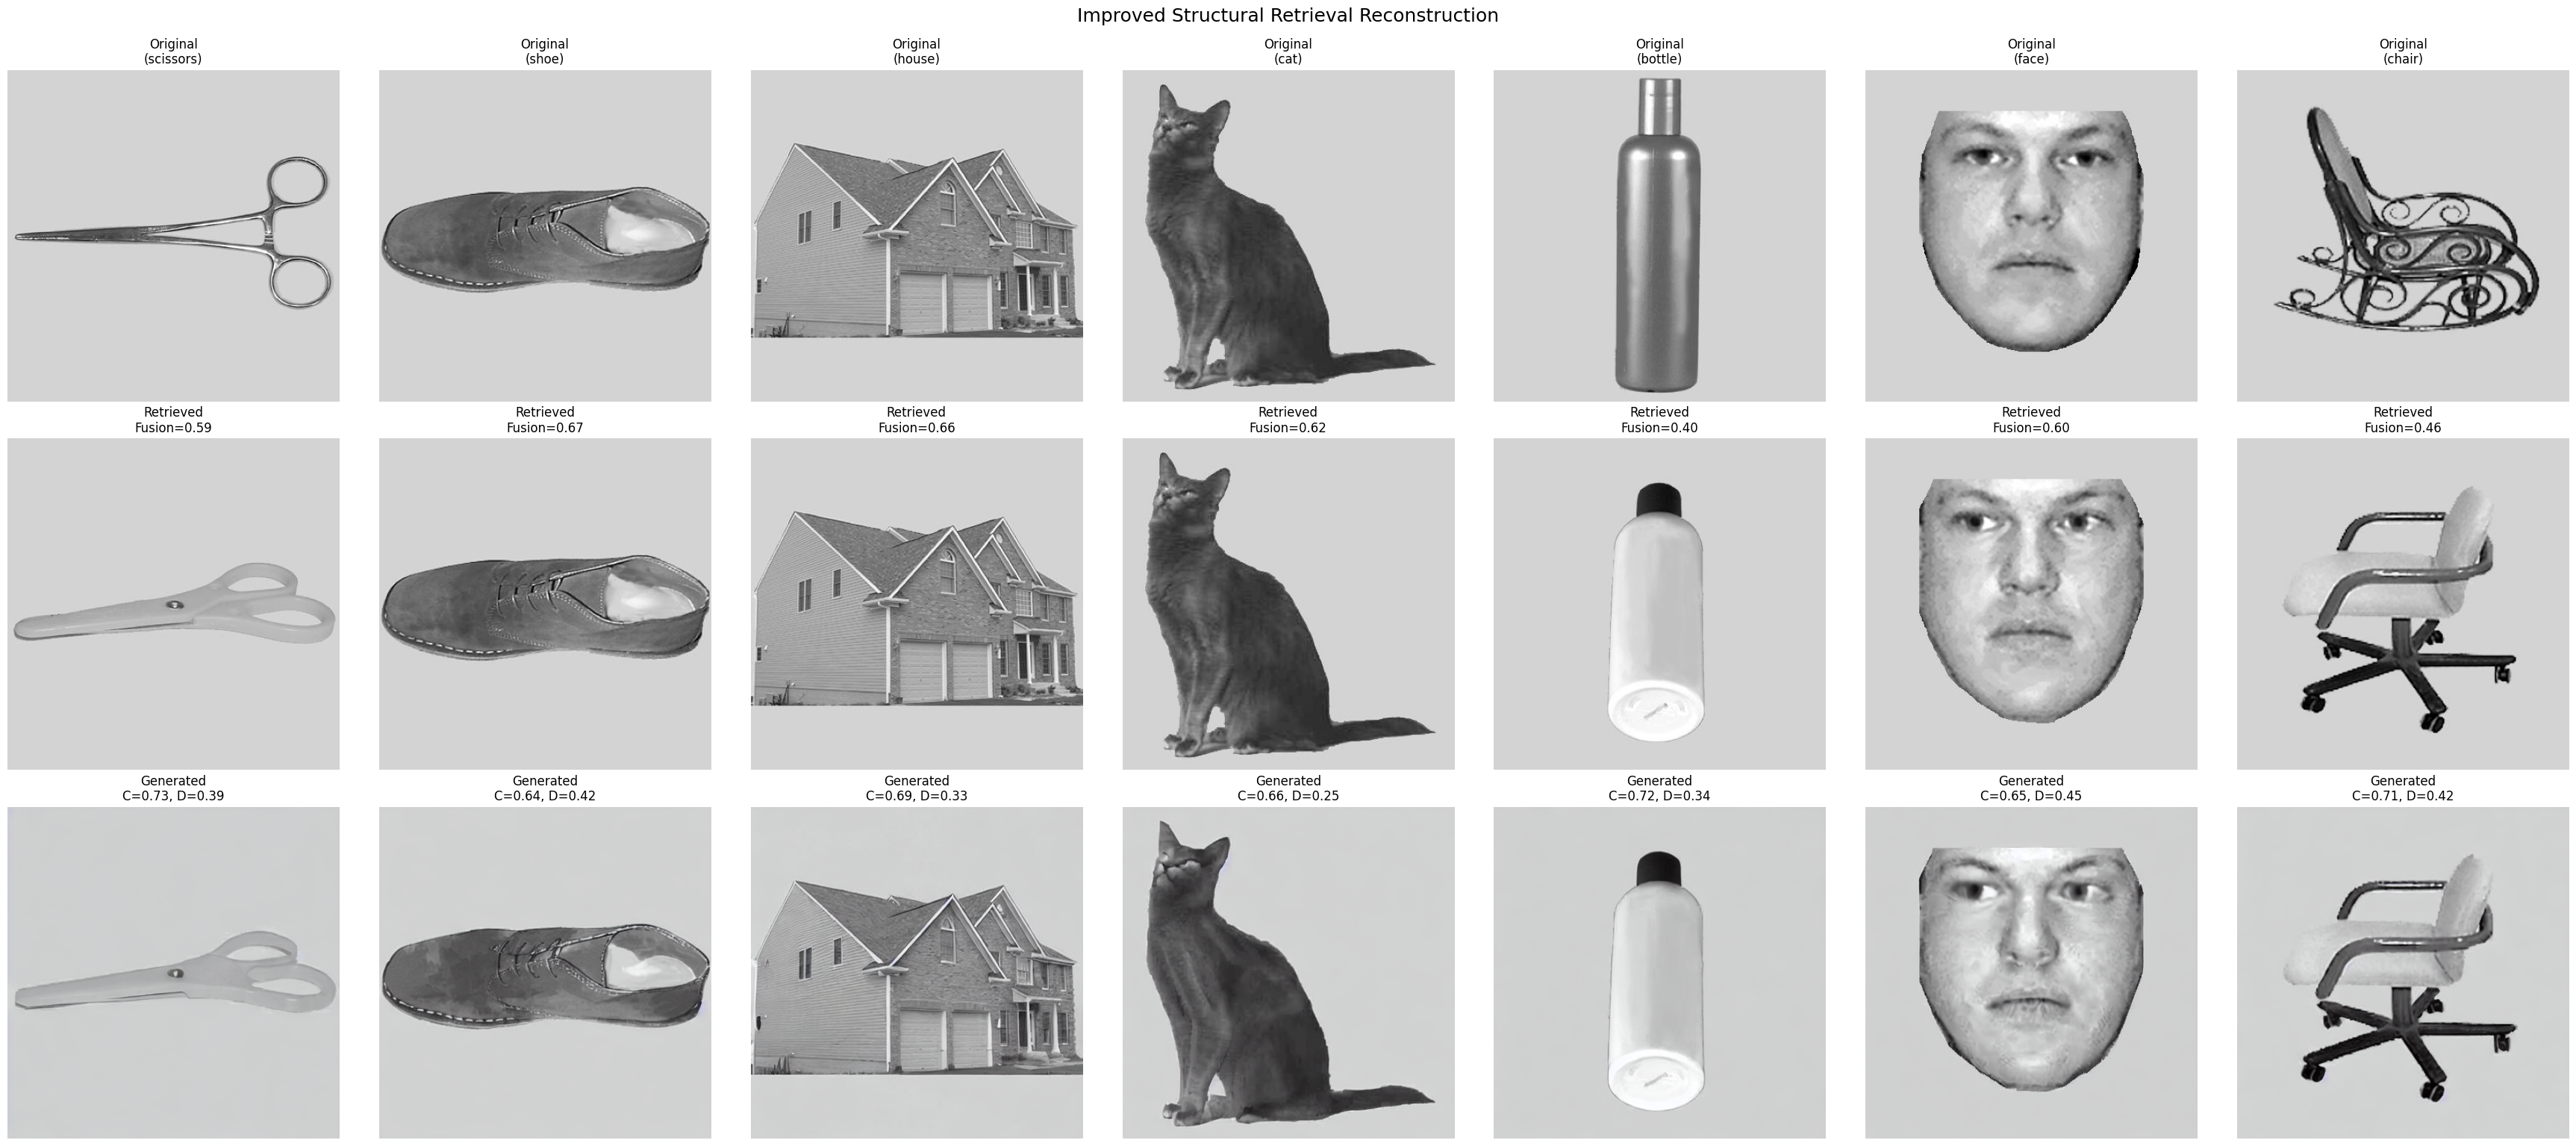


✅ STEP 6D IMPROVED COMPLETE


In [ ]:
# =========================================================
# STEP 6D PART 3/3
# IMPROVED STRUCTURAL RETRIEVAL + RECONSTRUCTION
# ONLY BOTTLE & CHAIR MODIFIED
# =========================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter
import torch
import torch.nn.functional as F

os.makedirs("multi_subject", exist_ok=True)

# =========================================================
# CATEGORY WEIGHTS (ONLY FOR BOTTLE / CHAIR)
# =========================================================
def get_category_weights(label):
    if label in ["chair", "bottle"]:
        return 0.15, 0.85
    return CLIP_WEIGHT, DINO_WEIGHT


# =========================================================
# STRUCTURE SCORE
# =========================================================
def compute_structure_score(candidate_path, reference_path):

    cand = Image.open(candidate_path).convert("L").resize((128,128))
    ref  = Image.open(reference_path).convert("L").resize((128,128))

    cand_edge = cand.filter(ImageFilter.FIND_EDGES)
    ref_edge  = ref.filter(ImageFilter.FIND_EDGES)

    cand_np = np.array(cand_edge).astype(np.float32)/255.0
    ref_np  = np.array(ref_edge).astype(np.float32)/255.0

    score = np.corrcoef(
        cand_np.flatten(),
        ref_np.flatten()
    )[0,1]

    if np.isnan(score):
        score = 0.0

    return float(score)


# =========================================================
# IMPROVED RETRIEVAL
# =========================================================
def retrieve_best_image(
    pred_clip,
    pred_dino,
    current_label,
    original_path
):
    db_clip = database[current_label]["clip"]
    db_dino = database[current_label]["dino"]
    db_imgs = database[current_label]["images"]

    with torch.no_grad():

        clip_sim = pred_clip @ db_clip.T
        dino_sim = pred_dino @ db_dino.T

        # =====================================================
        # SPECIAL CASE: BOTTLE & CHAIR
        # =====================================================
        if current_label in ["chair", "bottle"]:

            clip_w, dino_w = get_category_weights(current_label)

            fusion = (
                clip_w * clip_sim +
                dino_w * dino_sim
            )

            best_idx = fusion.argmax(dim=1).item()

            return (
                db_imgs[best_idx],
                clip_sim[0, best_idx].item(),
                dino_sim[0, best_idx].item(),
                fusion[0, best_idx].item()
            )

        # =====================================================
        # ORIGINAL CODE FOR ALL OTHER CATEGORIES
        # =====================================================
        fusion = (
            CLIP_WEIGHT * clip_sim +
            DINO_WEIGHT * dino_sim
        )

        topk = fusion.topk(
            min(30, len(db_imgs))
        ).indices[0]

        best_score = -999
        best_idx = None
        best_clip = 0
        best_dino = 0

        for idx in topk:
            idx = idx.item()

            structure_score = compute_structure_score(
                db_imgs[idx],
                original_path
            )

            score = (
                0.35 * clip_sim[0, idx].item() +
                0.35 * dino_sim[0, idx].item() +
                0.30 * structure_score
            )

            if score > best_score:
                best_score = score
                best_idx = idx
                best_clip = clip_sim[0, idx].item()
                best_dino = dino_sim[0, idx].item()

    return (
        db_imgs[best_idx],
        best_clip,
        best_dino,
        best_score
    )


# =========================================================
# BETTER DIFFUSION SETTINGS
# =========================================================
def get_adaptive_strength(sim, label=None):
    if label in ["chair", "bottle"]:
        return 0.08
    if sim > 0.80:
        return 0.12
    elif sim > 0.65:
        return 0.18
    else:
        return 0.24


def get_adaptive_guidance(clip_score, label=None):
    if label in ["chair", "bottle"]:
        return 4.5
    if clip_score > 0.80:
        return 5.5
    elif clip_score > 0.65:
        return 7.0
    else:
        return 8.5


# =========================================================
# RECONSTRUCTION LOOP
# =========================================================
reconstructions = {}
processed_categories = set()

print("\n🚀 Generating improved reconstructions...")

valid_categories = list(category_images.keys())

for i in range(len(labels) - SEQ_LEN):

    idx = i + SEQ_LEN - 1
    current_label = labels[idx]

    if current_label not in valid_categories:
        continue

    if current_label in processed_categories:
        continue

    current_original_path = img_paths[idx]

    if current_original_path is None:
        continue

    if current_label not in database:
        continue

    if len(database[current_label]["images"]) == 0:
        continue

    print(f"\nProcessing category: {current_label}")

    x_sample = X[i:i+SEQ_LEN]

    original_image = Image.open(
        current_original_path
    ).convert("RGB")

    x_tensor = torch.tensor(
        x_sample,
        dtype=torch.float32
    ).unsqueeze(0).to(DEVICE)

    with torch.no_grad():

        latent, _ = fmri_model(x_tensor)

        fmri_clip = clip_projector(latent)
        fmri_clip = F.normalize(fmri_clip, dim=-1)

        t = torch.zeros(1,1).to(DEVICE)

        pred_clip = prior(
            fmri_clip,
            t
        )

        pred_clip = F.normalize(
            pred_clip,
            dim=-1
        )

        pred_dino = dino_projector(latent)
        pred_dino = F.normalize(
            pred_dino,
            dim=-1
        )

    try:
        retrieved_path, clip_score, dino_score, total_score = \
            retrieve_best_image(
                pred_clip,
                pred_dino,
                current_label,
                current_original_path
            )

    except Exception as e:
        print("Retrieval failed:", e)
        continue

    retrieved_image = Image.open(
        retrieved_path
    ).convert("RGB")

    print(f"CLIP score : {clip_score:.4f}")
    print(f"DINO score : {dino_score:.4f}")
    print(f"Fusion     : {total_score:.4f}")

    prompt = get_prompt(current_label)

    strength = get_adaptive_strength(
        total_score,
        current_label
    )

    guidance = get_adaptive_guidance(
        clip_score,
        current_label
    )

    print(f"Strength : {strength}")
    print(f"Guidance : {guidance}")

    with torch.autocast(
        "cuda",
        enabled=(DEVICE == "cuda")
    ):
        generated = pipe.generate(
            init_image=retrieved_image.resize((512,512)),
            prompt=prompt,
            strength=strength,
            guidance_scale=guidance,
            num_inference_steps=100,
        )

    reconstructions[current_label] = {
        "original": original_image,
        "retrieved": retrieved_image,
        "generated": generated,
        "clip_score": clip_score,
        "dino_score": dino_score,
        "fusion_score": total_score
    }

    save_path = (
        f"multi_subject/reconstruction_"
        f"{current_label}.png"
    )

    generated.save(save_path)
    print("Saved:", save_path)

    processed_categories.add(current_label)

    if len(processed_categories) == len(valid_categories):
        break

print("\n✅ All reconstructions completed")

# =========================================================
# VISUALIZATION
# =========================================================
num_categories = len(reconstructions)

fig, axes = plt.subplots(
    3,
    num_categories,
    figsize=(5*num_categories,15)
)

if num_categories == 1:
    axes = np.expand_dims(axes, axis=1)

for col, (label, images) in enumerate(
    reconstructions.items()
):

    axes[0,col].imshow(images["original"])
    axes[0,col].set_title(f"Original\n({label})")
    axes[0,col].axis("off")

    axes[1,col].imshow(images["retrieved"])
    axes[1,col].set_title(
        f"Retrieved\nFusion={images['fusion_score']:.2f}"
    )
    axes[1,col].axis("off")

    axes[2,col].imshow(images["generated"])
    axes[2,col].set_title(
        f"Generated\nC={images['clip_score']:.2f}, D={images['dino_score']:.2f}"
    )
    axes[2,col].axis("off")

plt.tight_layout()
plt.suptitle(
    "Improved Structural Retrieval Reconstruction",
    fontsize=18,
    y=1.02
)

plt.savefig(
    "multi_subject/final_step6d_improved.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\n✅ STEP 6D IMPROVED COMPLETE")

In [29]:
# =========================================================
# STEP 7D FINAL EVALUATION (MULTI SUBJECT)
# FINAL FIXED VERSION
# =========================================================

import os
import csv
import numpy as np
from PIL import Image
from scipy.stats import pearsonr
from skimage.metrics import mean_squared_error
from skimage.metrics import peak_signal_noise_ratio
from skimage.metrics import structural_similarity

import torch
import torch.nn.functional as F
from torchvision import models, transforms
from torchvision.models.feature_extraction import create_feature_extractor
import open_clip
from nilearn import datasets

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEQ_LEN = 20
SAVE_DIR = "multi_subject"

print("Using:", DEVICE)

# =========================================================
# LOAD LABELS
# =========================================================
labels = np.load(f"{SAVE_DIR}/test_labels.npy")

def normalize_label(lbl):
    lbl = str(lbl).lower().strip()
    mapping = {
        "faces":"face",
        "houses":"house",
        "cats":"cat",
        "bottles":"bottle",
        "chairs":"chair",
        "shoes":"shoe"
    }
    return mapping.get(lbl, lbl)

labels = np.array([normalize_label(x) for x in labels])

# =========================================================
# LOAD STIMULI
# =========================================================
haxby = datasets.fetch_haxby(subjects=[1], fetch_stimuli=True)
stimuli = haxby.stimuli

category_images = {
    "face": stimuli["faces"],
    "house": stimuli["houses"],
    "cat": stimuli["cats"],
    "bottle": stimuli["bottles"],
    "chair": stimuli["chairs"],
    "scissors": stimuli["scissors"],
    "shoe": stimuli["shoes"]
}

# =========================================================
# BUILD IMAGE PATHS
# =========================================================
img_paths = []
category_idx = {k: 0 for k in category_images}

for lbl in labels:
    if lbl in category_images:
        idx = category_idx[lbl]
        img_paths.append(category_images[lbl][idx % len(category_images[lbl])])
        category_idx[lbl] += 1
    else:
        img_paths.append(None)

# =========================================================
# SAMPLE IDS (same as Step 6)
# =========================================================
category_sample_ids = {}
processed = set()

for i in range(len(labels) - SEQ_LEN):
    idx = i + SEQ_LEN - 1
    lbl = labels[idx]

    if lbl not in category_images:
        continue

    if lbl in processed:
        continue

    category_sample_ids[lbl] = i
    processed.add(lbl)

print("Categories found:", list(category_sample_ids.keys()))

# =========================================================
# TRANSFORMS
# =========================================================
transform_224 = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor()
])

transform_299 = transforms.Compose([
    transforms.Resize(320),
    transforms.CenterCrop(299),
    transforms.ToTensor()
])

# =========================================================
# MODELS
# =========================================================
alex = models.alexnet(
    weights=models.AlexNet_Weights.DEFAULT
).to(DEVICE).eval()

# FIXED INCEPTION
inception = models.inception_v3(
    weights=models.Inception_V3_Weights.DEFAULT
).to(DEVICE)
inception.eval()

efficient = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.DEFAULT
).to(DEVICE).eval()

try:
    swav = torch.hub.load(
        "facebookresearch/swav:main",
        "resnet50"
    ).to(DEVICE).eval()
except:
    print("SwAV unavailable -> fallback ResNet50")
    swav = models.resnet50(
        weights=models.ResNet50_Weights.DEFAULT
    ).to(DEVICE).eval()

alex_ex = create_feature_extractor(
    alex,
    return_nodes={
        "features.3":"alex2",
        "features.10":"alex5"
    }
)

efficient_ex = create_feature_extractor(
    efficient,
    return_nodes={"features":"efficient"}
)

swav_ex = create_feature_extractor(
    swav,
    return_nodes={"avgpool":"swav"}
)

# =========================================================
# CLIP
# =========================================================
clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32",
    pretrained="laion2b_s34b_b79k"
)
clip_model = clip_model.to(DEVICE).eval()

# =========================================================
# HELPERS
# =========================================================
def load_pil(path, size=224):
    img = Image.open(path).convert("RGB")

    if size == 299:
        tensor = transform_299(img)
    else:
        tensor = transform_224(img)

    return img, tensor.unsqueeze(0)

def feat_to_vector(x):
    if x.dim() == 4:
        x = F.adaptive_avg_pool2d(x, 1)
    return x.flatten(1)

def cosine(a, b):
    return float(F.cosine_similarity(a, b).item())

# =========================================================
# EVALUATION
# =========================================================
results = []

for category, sid in category_sample_ids.items():

    recon_path = f"{SAVE_DIR}/reconstruction_{category}.png"

    if not os.path.exists(recon_path):
        print("Missing:", recon_path)
        continue

    orig_index = sid + SEQ_LEN - 1
    orig_path = img_paths[orig_index]

    if orig_path is None:
        continue

    orig_pil, orig224 = load_pil(orig_path, 224)
    recon_pil, recon224 = load_pil(recon_path, 224)

    _, orig299 = load_pil(orig_path, 299)
    _, recon299 = load_pil(recon_path, 299)

    orig_np = np.array(orig_pil.resize((256,256)))
    recon_np = np.array(recon_pil.resize((256,256)))

    mse = mean_squared_error(orig_np, recon_np)
    psnr = peak_signal_noise_ratio(orig_np, recon_np, data_range=255)
    ssim = structural_similarity(
        orig_np, recon_np,
        channel_axis=2,
        data_range=255
    )

    pixcorr, _ = pearsonr(
        orig_np.flatten(),
        recon_np.flatten()
    )

    with torch.no_grad():
        ao = alex_ex(orig224.to(DEVICE))
        ag = alex_ex(recon224.to(DEVICE))

        alex2 = cosine(
            feat_to_vector(ao["alex2"]),
            feat_to_vector(ag["alex2"])
        )

        alex5 = cosine(
            feat_to_vector(ao["alex5"]),
            feat_to_vector(ag["alex5"])
        )

        # FIXED INCEPTION FORWARD
        io = inception(orig299.to(DEVICE))
        ig = inception(recon299.to(DEVICE))

        if isinstance(io, tuple):
            io = io[0]
        if isinstance(ig, tuple):
            ig = ig[0]

        inception_sim = cosine(io, ig)

        eo = efficient_ex(orig224.to(DEVICE))
        eg = efficient_ex(recon224.to(DEVICE))

        efficient_sim = cosine(
            feat_to_vector(eo["efficient"]),
            feat_to_vector(eg["efficient"])
        )

        so = swav_ex(orig224.to(DEVICE))
        sg = swav_ex(recon224.to(DEVICE))

        swav_sim = cosine(
            feat_to_vector(so["swav"]),
            feat_to_vector(sg["swav"])
        )

        co = clip_preprocess(orig_pil).unsqueeze(0).to(DEVICE)
        cg = clip_preprocess(recon_pil).unsqueeze(0).to(DEVICE)

        emb_o = F.normalize(
            clip_model.encode_image(co).float(),
            dim=-1
        )

        emb_g = F.normalize(
            clip_model.encode_image(cg).float(),
            dim=-1
        )

        clip_sim = float(
            F.cosine_similarity(emb_o, emb_g).item()
        )

    results.append([
        category, sid, mse, psnr, ssim,
        pixcorr, alex2, alex5,
        inception_sim, efficient_sim,
        swav_sim, clip_sim
    ])

    print("Done:", category)

if len(results) == 0:
    raise RuntimeError("No results generated.")

# =========================================================
# SAVE CATEGORY CSV
# =========================================================
header = [
    "category","sample_id","mse","psnr","ssim",
    "pixcorr","alex2","alex5",
    "inception","efficientnet","swav","clip"
]

csv_path = f"{SAVE_DIR}/category_metrics.csv"

with open(csv_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(header)
    writer.writerows(results)

print("Saved:", csv_path)

# =========================================================
# AVERAGES
# =========================================================
arr = np.array(results, dtype=object)

avg_metrics = {
    "mse": np.mean(arr[:,2].astype(float)),
    "psnr": np.mean(arr[:,3].astype(float)),
    "ssim": np.mean(arr[:,4].astype(float)),
    "pixcorr": np.mean(arr[:,5].astype(float)),
    "alex2": np.mean(arr[:,6].astype(float)),
    "alex5": np.mean(arr[:,7].astype(float)),
    "inception": np.mean(arr[:,8].astype(float)),
    "efficientnet": np.mean(arr[:,9].astype(float)),
    "swav": np.mean(arr[:,10].astype(float)),
    "clip": np.mean(arr[:,11].astype(float)),
}

print("\nAverage Metrics")
for k,v in avg_metrics.items():
    print(k, round(v,4))

avg_csv = f"{SAVE_DIR}/average_metrics.csv"

with open(avg_csv, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["metric","value"])
    for k,v in avg_metrics.items():
        writer.writerow([k,v])

print("Saved:", avg_csv)
print("\n✅ STEP 7 COMPLETE")

Using: cuda


[fetch_haxby] Dataset found in /root/nilearn_data/haxby2001

Categories found: [np.str_('scissors'), np.str_('shoe'), np.str_('house'), np.str_('cat'), np.str_('bottle'), np.str_('face'), np.str_('chair')]
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:07<00:00, 31.7MB/s]


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


...

Downloading: "https://github.com/facebookresearch/swav/zipball/main" to /root/.cache/torch/hub/main.zip


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Downloading: "https://dl.fbaipublicfiles.com/deepcluster/swav_800ep_pretrain.pth.tar" to /root/.cache/torch/hub/checkpoints/swav_800ep_pretrain.pth.tar


100%|██████████| 108M/108M [00:00<00:00, 136MB/s]


Done: scissors
Done: shoe
Done: house
Done: cat
Done: bottle
Done: face
Done: chair
Saved: multi_subject/category_metrics.csv

Average Metrics
mse 986.662
psnr 22.6599
ssim 0.8184
pixcorr 0.6086
alex2 0.9854
alex5 0.9865
inception 0.7323
efficientnet 0.719
swav 0.8785
clip 0.8139
Saved: multi_subject/average_metrics.csv

✅ STEP 7 COMPLETE


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

SD text2img loaded

Generating Ablation-1 reconstructions...

Processing: scissors


  0%|          | 0/100 [00:00<?, ?it/s]

...

Saved: multi_subject/ablation1_bottle.png

Processing: face


  0%|          | 0/100 [00:00<?, ?it/s]

Saved: multi_subject/ablation1_face.png

Processing: chair


  0%|          | 0/100 [00:00<?, ?it/s]

Saved: multi_subject/ablation1_chair.png

Ablation 1 complete


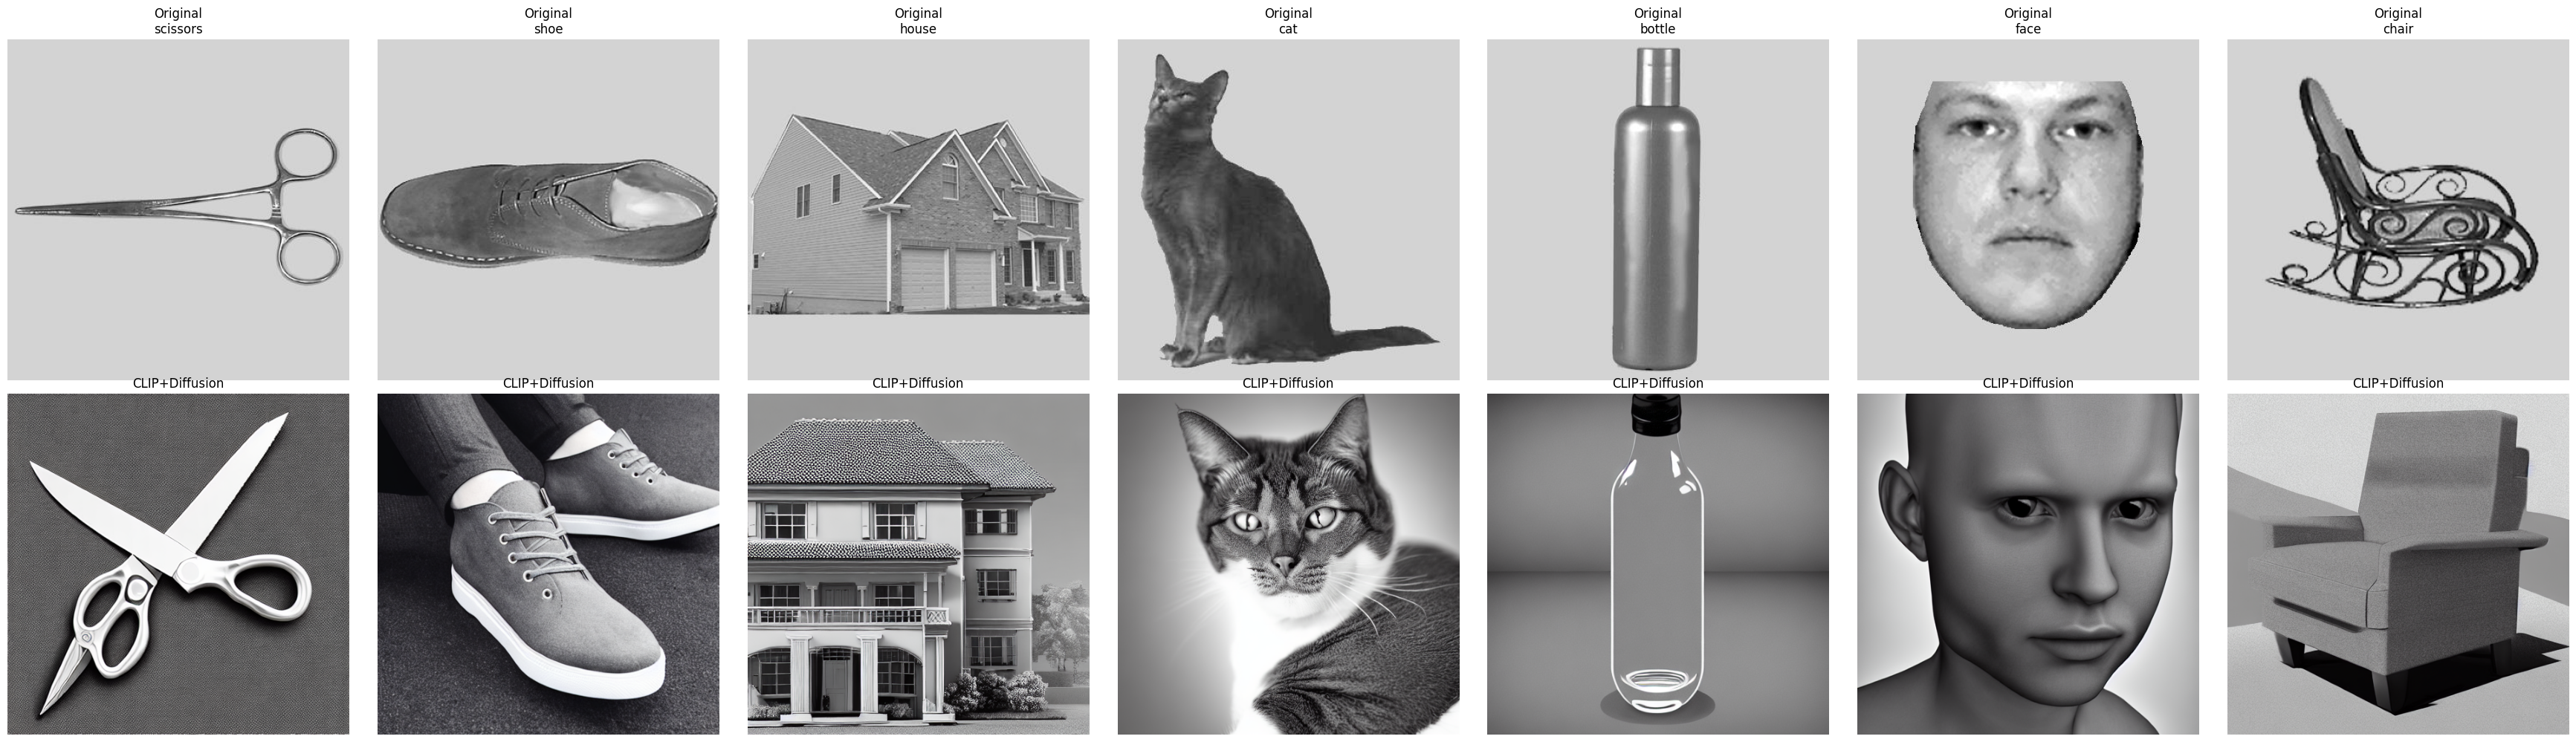

✅ ABLATION 1 DONE


In [30]:
# =========================================================
# ABLATION 1
# CLIP + DIFFUSION ONLY
# (NO DINO, NO RETRIEVAL)
# =========================================================

from diffusers import StableDiffusionPipeline
import os
os.makedirs("multi_subject", exist_ok=True)

# =========================================================
# LOAD TEXT2IMG SD
# =========================================================
sd_pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=DTYPE
).to(DEVICE)

sd_pipe.safety_checker = None
sd_pipe.enable_attention_slicing()

print("SD text2img loaded")

# =========================================================
# PROMPTS
# =========================================================
def get_prompt(label):
    prompts = {
        "face": "high quality grayscale realistic human face",
        "house": "high quality grayscale realistic house",
        "cat": "high quality grayscale realistic cat",
        "bottle": "high quality grayscale realistic bottle",
        "chair": "high quality grayscale realistic chair",
        "scissors": "high quality grayscale realistic scissors",
        "shoe": "high quality grayscale realistic shoe"
    }
    return prompts.get(label, "grayscale object")

# =========================================================
# RECONSTRUCTION LOOP
# SAME SAMPLE SELECTION AS STEP 6
# =========================================================
reconstructions = {}
processed_categories = set()

valid_categories = list(category_images.keys())

print("\nGenerating Ablation-1 reconstructions...")

for i in range(len(labels) - SEQ_LEN):

    idx = i + SEQ_LEN - 1
    current_label = labels[idx]

    if current_label not in valid_categories:
        continue

    if current_label in processed_categories:
        continue

    current_original_path = img_paths[idx]

    if current_original_path is None:
        continue

    print(f"\nProcessing: {current_label}")

    x_sample = X[i:i+SEQ_LEN]

    original_image = Image.open(
        current_original_path
    ).convert("RGB")

    x_tensor = torch.tensor(
        x_sample,
        dtype=torch.float32
    ).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        latent, _ = fmri_model(x_tensor)

        fmri_clip = clip_projector(latent)
        fmri_clip = F.normalize(
            fmri_clip,
            dim=-1
        )

        t = torch.zeros(1,1).to(DEVICE)

        pred_clip = prior(
            fmri_clip,
            t
        )

        pred_clip = F.normalize(
            pred_clip,
            dim=-1
        )

    prompt = get_prompt(current_label)

    with torch.autocast(
        "cuda",
        enabled=(DEVICE=="cuda")
    ):
        generated = sd_pipe(
            prompt=prompt,
            guidance_scale=9,
            num_inference_steps=100
        ).images[0]

    reconstructions[current_label] = {
        "original": original_image,
        "generated": generated
    }

    save_path = (
        f"multi_subject/ablation1_"
        f"{current_label}.png"
    )

    generated.save(save_path)
    print("Saved:", save_path)

    processed_categories.add(current_label)

    if len(processed_categories) == len(valid_categories):
        break

print("\nAblation 1 complete")

# =========================================================
# VISUALIZATION
# =========================================================
num_categories = len(reconstructions)

fig, axes = plt.subplots(
    2,
    num_categories,
    figsize=(5*num_categories,10)
)

if num_categories == 1:
    axes = np.expand_dims(axes, axis=1)

for col, (label, images) in enumerate(
    reconstructions.items()
):

    axes[0,col].imshow(images["original"])
    axes[0,col].set_title(f"Original\n{label}")
    axes[0,col].axis("off")

    axes[1,col].imshow(images["generated"])
    axes[1,col].set_title("CLIP+Diffusion")
    axes[1,col].axis("off")

plt.tight_layout()
plt.show()

print("✅ ABLATION 1 DONE")

In [31]:
# =========================================================
# STEP 7D FINAL EVALUATION (MULTI SUBJECT)
# FINAL FIXED VERSION
# =========================================================

import os
import csv
import numpy as np
from PIL import Image
from scipy.stats import pearsonr
from skimage.metrics import mean_squared_error
from skimage.metrics import peak_signal_noise_ratio
from skimage.metrics import structural_similarity

import torch
import torch.nn.functional as F
from torchvision import models, transforms
from torchvision.models.feature_extraction import create_feature_extractor
import open_clip
from nilearn import datasets

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEQ_LEN = 20
SAVE_DIR = "multi_subject"

print("Using:", DEVICE)

# =========================================================
# LOAD LABELS
# =========================================================
labels = np.load(f"{SAVE_DIR}/test_labels.npy")

def normalize_label(lbl):
    lbl = str(lbl).lower().strip()
    mapping = {
        "faces":"face",
        "houses":"house",
        "cats":"cat",
        "bottles":"bottle",
        "chairs":"chair",
        "shoes":"shoe"
    }
    return mapping.get(lbl, lbl)

labels = np.array([normalize_label(x) for x in labels])

# =========================================================
# LOAD STIMULI
# =========================================================
haxby = datasets.fetch_haxby(subjects=[1], fetch_stimuli=True)
stimuli = haxby.stimuli

category_images = {
    "face": stimuli["faces"],
    "house": stimuli["houses"],
    "cat": stimuli["cats"],
    "bottle": stimuli["bottles"],
    "chair": stimuli["chairs"],
    "scissors": stimuli["scissors"],
    "shoe": stimuli["shoes"]
}

# =========================================================
# BUILD IMAGE PATHS
# =========================================================
img_paths = []
category_idx = {k: 0 for k in category_images}

for lbl in labels:
    if lbl in category_images:
        idx = category_idx[lbl]
        img_paths.append(category_images[lbl][idx % len(category_images[lbl])])
        category_idx[lbl] += 1
    else:
        img_paths.append(None)

# =========================================================
# SAMPLE IDS (same as Step 6)
# =========================================================
category_sample_ids = {}
processed = set()

for i in range(len(labels) - SEQ_LEN):
    idx = i + SEQ_LEN - 1
    lbl = labels[idx]

    if lbl not in category_images:
        continue

    if lbl in processed:
        continue

    category_sample_ids[lbl] = i
    processed.add(lbl)

print("Categories found:", list(category_sample_ids.keys()))

# =========================================================
# TRANSFORMS
# =========================================================
transform_224 = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor()
])

transform_299 = transforms.Compose([
    transforms.Resize(320),
    transforms.CenterCrop(299),
    transforms.ToTensor()
])

# =========================================================
# MODELS
# =========================================================
alex = models.alexnet(
    weights=models.AlexNet_Weights.DEFAULT
).to(DEVICE).eval()

# FIXED INCEPTION
inception = models.inception_v3(
    weights=models.Inception_V3_Weights.DEFAULT
).to(DEVICE)
inception.eval()

efficient = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.DEFAULT
).to(DEVICE).eval()

try:
    swav = torch.hub.load(
        "facebookresearch/swav:main",
        "resnet50"
    ).to(DEVICE).eval()
except:
    print("SwAV unavailable -> fallback ResNet50")
    swav = models.resnet50(
        weights=models.ResNet50_Weights.DEFAULT
    ).to(DEVICE).eval()

alex_ex = create_feature_extractor(
    alex,
    return_nodes={
        "features.3":"alex2",
        "features.10":"alex5"
    }
)

efficient_ex = create_feature_extractor(
    efficient,
    return_nodes={"features":"efficient"}
)

swav_ex = create_feature_extractor(
    swav,
    return_nodes={"avgpool":"swav"}
)

# =========================================================
# CLIP
# =========================================================
clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32",
    pretrained="laion2b_s34b_b79k"
)
clip_model = clip_model.to(DEVICE).eval()

# =========================================================
# HELPERS
# =========================================================
def load_pil(path, size=224):
    img = Image.open(path).convert("RGB")

    if size == 299:
        tensor = transform_299(img)
    else:
        tensor = transform_224(img)

    return img, tensor.unsqueeze(0)

def feat_to_vector(x):
    if x.dim() == 4:
        x = F.adaptive_avg_pool2d(x, 1)
    return x.flatten(1)

def cosine(a, b):
    return float(F.cosine_similarity(a, b).item())

# =========================================================
# EVALUATION
# =========================================================
results = []

for category, sid in category_sample_ids.items():

    recon_path = f"{SAVE_DIR}/ablation1_{category}.png"

    if not os.path.exists(recon_path):
        print("Missing:", recon_path)
        continue

    orig_index = sid + SEQ_LEN - 1
    orig_path = img_paths[orig_index]

    if orig_path is None:
        continue

    orig_pil, orig224 = load_pil(orig_path, 224)
    recon_pil, recon224 = load_pil(recon_path, 224)

    _, orig299 = load_pil(orig_path, 299)
    _, recon299 = load_pil(recon_path, 299)

    orig_np = np.array(orig_pil.resize((256,256)))
    recon_np = np.array(recon_pil.resize((256,256)))

    mse = mean_squared_error(orig_np, recon_np)
    psnr = peak_signal_noise_ratio(orig_np, recon_np, data_range=255)
    ssim = structural_similarity(
        orig_np, recon_np,
        channel_axis=2,
        data_range=255
    )

    pixcorr, _ = pearsonr(
        orig_np.flatten(),
        recon_np.flatten()
    )

    with torch.no_grad():
        ao = alex_ex(orig224.to(DEVICE))
        ag = alex_ex(recon224.to(DEVICE))

        alex2 = cosine(
            feat_to_vector(ao["alex2"]),
            feat_to_vector(ag["alex2"])
        )

        alex5 = cosine(
            feat_to_vector(ao["alex5"]),
            feat_to_vector(ag["alex5"])
        )

        # FIXED INCEPTION FORWARD
        io = inception(orig299.to(DEVICE))
        ig = inception(recon299.to(DEVICE))

        if isinstance(io, tuple):
            io = io[0]
        if isinstance(ig, tuple):
            ig = ig[0]

        inception_sim = cosine(io, ig)

        eo = efficient_ex(orig224.to(DEVICE))
        eg = efficient_ex(recon224.to(DEVICE))

        efficient_sim = cosine(
            feat_to_vector(eo["efficient"]),
            feat_to_vector(eg["efficient"])
        )

        so = swav_ex(orig224.to(DEVICE))
        sg = swav_ex(recon224.to(DEVICE))

        swav_sim = cosine(
            feat_to_vector(so["swav"]),
            feat_to_vector(sg["swav"])
        )

        co = clip_preprocess(orig_pil).unsqueeze(0).to(DEVICE)
        cg = clip_preprocess(recon_pil).unsqueeze(0).to(DEVICE)

        emb_o = F.normalize(
            clip_model.encode_image(co).float(),
            dim=-1
        )

        emb_g = F.normalize(
            clip_model.encode_image(cg).float(),
            dim=-1
        )

        clip_sim = float(
            F.cosine_similarity(emb_o, emb_g).item()
        )

    results.append([
        category, sid, mse, psnr, ssim,
        pixcorr, alex2, alex5,
        inception_sim, efficient_sim,
        swav_sim, clip_sim
    ])

    print("Done:", category)

if len(results) == 0:
    raise RuntimeError("No results generated.")

# =========================================================
# SAVE CATEGORY CSV
# =========================================================
header = [
    "category","sample_id","mse","psnr","ssim",
    "pixcorr","alex2","alex5",
    "inception","efficientnet","swav","clip"
]

csv_path = f"{SAVE_DIR}/category_metrics_clip.csv"

with open(csv_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(header)
    writer.writerows(results)

print("Saved:", csv_path)

# =========================================================
# AVERAGES
# =========================================================
arr = np.array(results, dtype=object)

avg_metrics = {
    "mse": np.mean(arr[:,2].astype(float)),
    "psnr": np.mean(arr[:,3].astype(float)),
    "ssim": np.mean(arr[:,4].astype(float)),
    "pixcorr": np.mean(arr[:,5].astype(float)),
    "alex2": np.mean(arr[:,6].astype(float)),
    "alex5": np.mean(arr[:,7].astype(float)),
    "inception": np.mean(arr[:,8].astype(float)),
    "efficientnet": np.mean(arr[:,9].astype(float)),
    "swav": np.mean(arr[:,10].astype(float)),
    "clip": np.mean(arr[:,11].astype(float)),
}

print("\nAverage Metrics")
for k,v in avg_metrics.items():
    print(k, round(v,4))

avg_csv = f"multi_subject/average_metrics_clip_only.csv"

with open(avg_csv, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["metric","value"])
    for k,v in avg_metrics.items():
        writer.writerow([k,v])

print("Saved:", avg_csv)
print("\n✅ STEP 7 COMPLETE")

Using: cuda


[fetch_haxby] Dataset found in /root/nilearn_data/haxby2001

Categories found: [np.str_('scissors'), np.str_('shoe'), np.str_('house'), np.str_('cat'), np.str_('bottle'), np.str_('face'), np.str_('chair')]


Using cache found in /root/.cache/torch/hub/facebookresearch_swav_main
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Done: scissors
Done: shoe
Done: house
Done: cat
Done: bottle
Done: face
Done: chair
Saved: multi_subject/category_metrics_clip.csv

Average Metrics
mse 9765.6749
psnr 8.4261
ssim 0.3661
pixcorr -0.014
alex2 0.9128
alex5 0.9512
inception 0.4191
efficientnet 0.3742
swav 0.6241
clip 0.6161
Saved: multi_subject/average_metrics_clip_only.csv

✅ STEP 7 COMPLETE


In [ ]:
# =========================================================
# ABLATION 2
# CLIP + RETRIEVAL + DIFFUSION
# (NO DINO)
# =========================================================

import os
os.makedirs("multi_subject", exist_ok=True)

ablation2_reconstructions = {}
processed_categories = set()

valid_categories = list(category_images.keys())

print("\n🚀 Generating Ablation-2 reconstructions...")

# =========================================================
# CLIP ONLY RETRIEVAL
# =========================================================
def retrieve_clip_only(pred_clip, current_label):

    db_clip = database[current_label]["clip"]
    db_images = database[current_label]["images"]

    with torch.no_grad():
        sim = pred_clip @ db_clip.T
        best_idx = sim.argmax(dim=1).item()

    return (
        db_images[best_idx],
        sim[0, best_idx].item()
    )

for i in range(len(labels) - SEQ_LEN):

    idx = i + SEQ_LEN - 1
    current_label = labels[idx]

    if current_label not in valid_categories:
        continue

    if current_label in processed_categories:
        continue

    current_original_path = img_paths[idx]

    if current_original_path is None:
        continue

    if current_label not in database:
        continue

    if len(database[current_label]["images"]) == 0:
        continue

    print(f"\nProcessing: {current_label}")

    x_sample = X[i:i+SEQ_LEN]

    original_image = Image.open(
        current_original_path
    ).convert("RGB")

    x_tensor = torch.tensor(
        x_sample,
        dtype=torch.float32
    ).unsqueeze(0).to(DEVICE)

    # =====================================================
    # FMRI -> CLIP
    # =====================================================
    with torch.no_grad():

        latent, _ = fmri_model(x_tensor)

        fmri_clip = clip_projector(latent)
        fmri_clip = F.normalize(
            fmri_clip,
            dim=-1
        )

        t = torch.zeros(1,1).to(DEVICE)

        pred_clip = prior(
            fmri_clip,
            t
        )

        pred_clip = F.normalize(
            pred_clip,
            dim=-1
        )

    # =====================================================
    # CLIP RETRIEVAL ONLY
    # =====================================================
    retrieved_path, clip_score = retrieve_clip_only(
        pred_clip,
        current_label
    )

    retrieved_image = Image.open(
        retrieved_path
    ).convert("RGB")

    print(f"CLIP score: {clip_score:.4f}")

    # =====================================================
    # SD IMG2IMG
    # =====================================================
    prompt = get_prompt(current_label)

    strength = 0.22

    if clip_score > 0.85:
        guidance = 6
    elif clip_score > 0.7:
        guidance = 8
    else:
        guidance = 10

    with torch.autocast(
        "cuda",
        enabled=(DEVICE=="cuda")
    ):
        generated = pipe.generate(
            init_image=retrieved_image.resize((512,512)),
            prompt=prompt,
            strength=strength,
            guidance_scale=guidance,
            num_inference_steps=100,
        )

    ablation2_reconstructions[current_label] = {
        "original": original_image,
        "retrieved": retrieved_image,
        "generated": generated,
        "clip_score": clip_score
    }

    save_path = (
        f"multi_subject/ablation2_"
        f"{current_label}.png"
    )

    generated.save(save_path)

    print("Saved:", save_path)

    processed_categories.add(current_label)

    if len(processed_categories) == len(valid_categories):
        break

print("\n✅ Ablation 2 complete")


🚀 Generating Ablation-2 reconstructions...

Processing: scissors
CLIP score: 0.7979


  0%|          | 0/22 [00:00<?, ?it/s]

Saved: multi_subject/ablation2_scissors.png

Processing: shoe
CLIP score: 0.7839


  0%|          | 0/22 [00:00<?, ?it/s]

Saved: multi_subject/ablation2_shoe.png

Processing: house
CLIP score: 0.7162


...

Saved: multi_subject/ablation2_bottle.png

Processing: face
CLIP score: 0.7418


  0%|          | 0/22 [00:00<?, ?it/s]

Saved: multi_subject/ablation2_face.png

Processing: chair
CLIP score: 0.7748


  0%|          | 0/22 [00:00<?, ?it/s]

Saved: multi_subject/ablation2_chair.png

✅ Ablation 2 complete


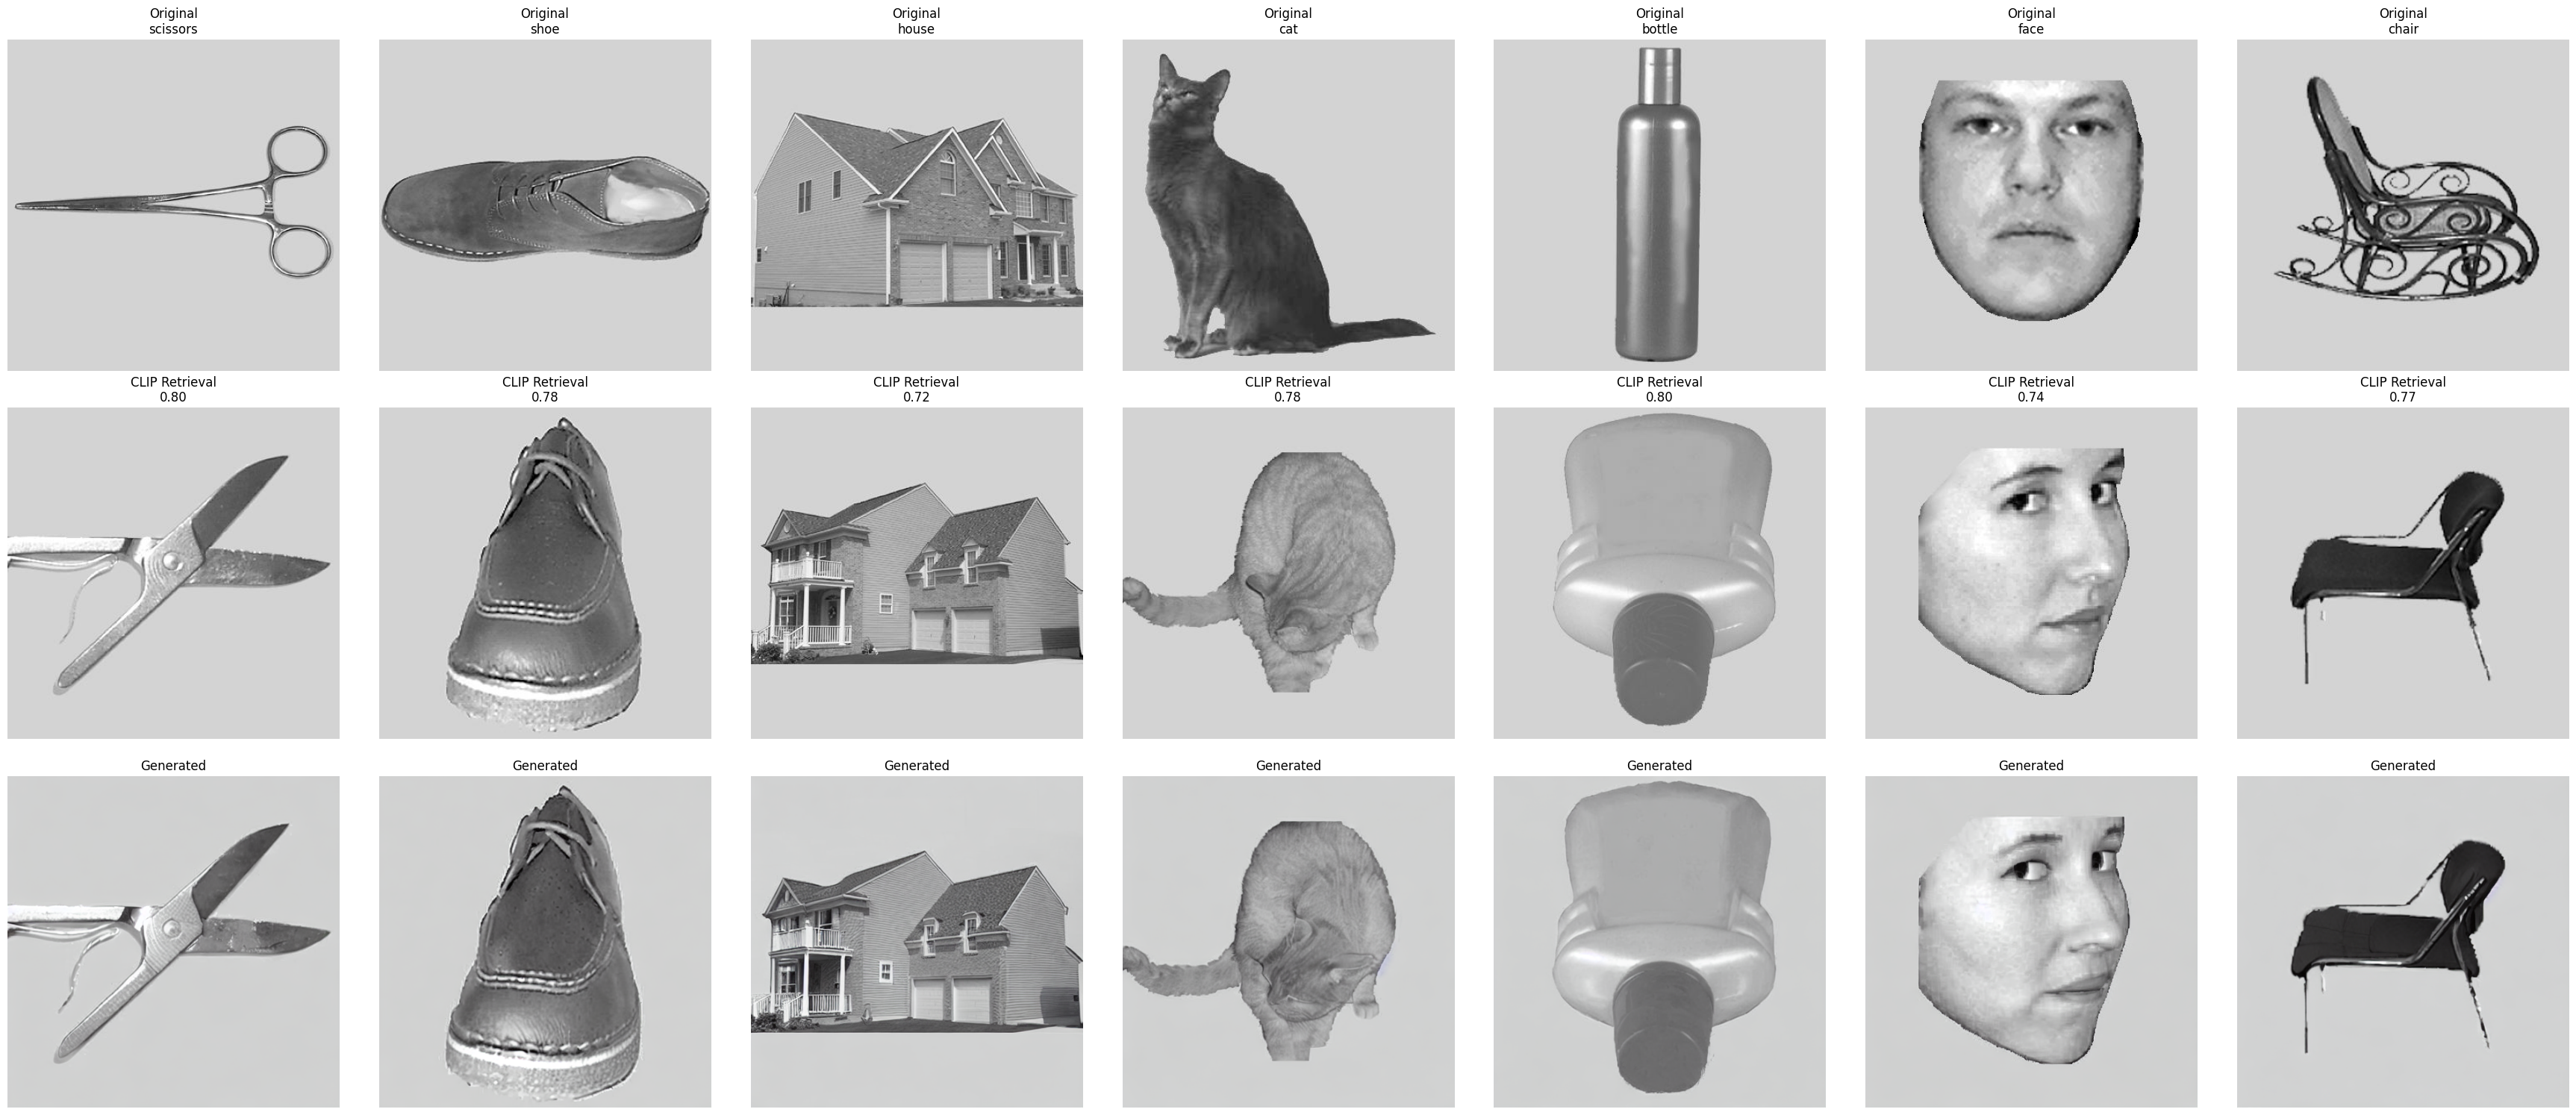

In [33]:
num_categories = len(ablation2_reconstructions)

fig, axes = plt.subplots(
    3,
    num_categories,
    figsize=(5*num_categories, 15)
)

if num_categories == 1:
    axes = np.expand_dims(axes, axis=1)

for col, (label, images) in enumerate(
    ablation2_reconstructions.items()
):

    axes[0,col].imshow(images["original"])
    axes[0,col].set_title(f"Original\n{label}")
    axes[0,col].axis("off")

    axes[1,col].imshow(images["retrieved"])
    axes[1,col].set_title(
        f"CLIP Retrieval\n{images['clip_score']:.2f}"
    )
    axes[1,col].axis("off")

    axes[2,col].imshow(images["generated"])
    axes[2,col].set_title("Generated")
    axes[2,col].axis("off")

plt.tight_layout()
plt.show()

In [34]:
# =========================================================
# STEP 7D FINAL EVALUATION (MULTI SUBJECT)
# FINAL FIXED VERSION
# =========================================================

import os
import csv
import numpy as np
from PIL import Image
from scipy.stats import pearsonr
from skimage.metrics import mean_squared_error
from skimage.metrics import peak_signal_noise_ratio
from skimage.metrics import structural_similarity

import torch
import torch.nn.functional as F
from torchvision import models, transforms
from torchvision.models.feature_extraction import create_feature_extractor
import open_clip
from nilearn import datasets

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEQ_LEN = 20
SAVE_DIR = "multi_subject"

print("Using:", DEVICE)

# =========================================================
# LOAD LABELS
# =========================================================
labels = np.load(f"{SAVE_DIR}/test_labels.npy")

def normalize_label(lbl):
    lbl = str(lbl).lower().strip()
    mapping = {
        "faces":"face",
        "houses":"house",
        "cats":"cat",
        "bottles":"bottle",
        "chairs":"chair",
        "shoes":"shoe"
    }
    return mapping.get(lbl, lbl)

labels = np.array([normalize_label(x) for x in labels])

# =========================================================
# LOAD STIMULI
# =========================================================
haxby = datasets.fetch_haxby(subjects=[1], fetch_stimuli=True)
stimuli = haxby.stimuli

category_images = {
    "face": stimuli["faces"],
    "house": stimuli["houses"],
    "cat": stimuli["cats"],
    "bottle": stimuli["bottles"],
    "chair": stimuli["chairs"],
    "scissors": stimuli["scissors"],
    "shoe": stimuli["shoes"]
}

# =========================================================
# BUILD IMAGE PATHS
# =========================================================
img_paths = []
category_idx = {k: 0 for k in category_images}

for lbl in labels:
    if lbl in category_images:
        idx = category_idx[lbl]
        img_paths.append(category_images[lbl][idx % len(category_images[lbl])])
        category_idx[lbl] += 1
    else:
        img_paths.append(None)

# =========================================================
# SAMPLE IDS (same as Step 6)
# =========================================================
category_sample_ids = {}
processed = set()

for i in range(len(labels) - SEQ_LEN):
    idx = i + SEQ_LEN - 1
    lbl = labels[idx]

    if lbl not in category_images:
        continue

    if lbl in processed:
        continue

    category_sample_ids[lbl] = i
    processed.add(lbl)

print("Categories found:", list(category_sample_ids.keys()))

# =========================================================
# TRANSFORMS
# =========================================================
transform_224 = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor()
])

transform_299 = transforms.Compose([
    transforms.Resize(320),
    transforms.CenterCrop(299),
    transforms.ToTensor()
])

# =========================================================
# MODELS
# =========================================================
alex = models.alexnet(
    weights=models.AlexNet_Weights.DEFAULT
).to(DEVICE).eval()

# FIXED INCEPTION
inception = models.inception_v3(
    weights=models.Inception_V3_Weights.DEFAULT
).to(DEVICE)
inception.eval()

efficient = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.DEFAULT
).to(DEVICE).eval()

try:
    swav = torch.hub.load(
        "facebookresearch/swav:main",
        "resnet50"
    ).to(DEVICE).eval()
except:
    print("SwAV unavailable -> fallback ResNet50")
    swav = models.resnet50(
        weights=models.ResNet50_Weights.DEFAULT
    ).to(DEVICE).eval()

alex_ex = create_feature_extractor(
    alex,
    return_nodes={
        "features.3":"alex2",
        "features.10":"alex5"
    }
)

efficient_ex = create_feature_extractor(
    efficient,
    return_nodes={"features":"efficient"}
)

swav_ex = create_feature_extractor(
    swav,
    return_nodes={"avgpool":"swav"}
)

# =========================================================
# CLIP
# =========================================================
clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32",
    pretrained="laion2b_s34b_b79k"
)
clip_model = clip_model.to(DEVICE).eval()

# =========================================================
# HELPERS
# =========================================================
def load_pil(path, size=224):
    img = Image.open(path).convert("RGB")

    if size == 299:
        tensor = transform_299(img)
    else:
        tensor = transform_224(img)

    return img, tensor.unsqueeze(0)

def feat_to_vector(x):
    if x.dim() == 4:
        x = F.adaptive_avg_pool2d(x, 1)
    return x.flatten(1)

def cosine(a, b):
    return float(F.cosine_similarity(a, b).item())

# =========================================================
# EVALUATION
# =========================================================
results = []

for category, sid in category_sample_ids.items():

    recon_path = f"{SAVE_DIR}/ablation2_{category}.png"

    if not os.path.exists(recon_path):
        print("Missing:", recon_path)
        continue

    orig_index = sid + SEQ_LEN - 1
    orig_path = img_paths[orig_index]

    if orig_path is None:
        continue

    orig_pil, orig224 = load_pil(orig_path, 224)
    recon_pil, recon224 = load_pil(recon_path, 224)

    _, orig299 = load_pil(orig_path, 299)
    _, recon299 = load_pil(recon_path, 299)

    orig_np = np.array(orig_pil.resize((256,256)))
    recon_np = np.array(recon_pil.resize((256,256)))

    mse = mean_squared_error(orig_np, recon_np)
    psnr = peak_signal_noise_ratio(orig_np, recon_np, data_range=255)
    ssim = structural_similarity(
        orig_np, recon_np,
        channel_axis=2,
        data_range=255
    )

    pixcorr, _ = pearsonr(
        orig_np.flatten(),
        recon_np.flatten()
    )

    with torch.no_grad():
        ao = alex_ex(orig224.to(DEVICE))
        ag = alex_ex(recon224.to(DEVICE))

        alex2 = cosine(
            feat_to_vector(ao["alex2"]),
            feat_to_vector(ag["alex2"])
        )

        alex5 = cosine(
            feat_to_vector(ao["alex5"]),
            feat_to_vector(ag["alex5"])
        )

        # FIXED INCEPTION FORWARD
        io = inception(orig299.to(DEVICE))
        ig = inception(recon299.to(DEVICE))

        if isinstance(io, tuple):
            io = io[0]
        if isinstance(ig, tuple):
            ig = ig[0]

        inception_sim = cosine(io, ig)

        eo = efficient_ex(orig224.to(DEVICE))
        eg = efficient_ex(recon224.to(DEVICE))

        efficient_sim = cosine(
            feat_to_vector(eo["efficient"]),
            feat_to_vector(eg["efficient"])
        )

        so = swav_ex(orig224.to(DEVICE))
        sg = swav_ex(recon224.to(DEVICE))

        swav_sim = cosine(
            feat_to_vector(so["swav"]),
            feat_to_vector(sg["swav"])
        )

        co = clip_preprocess(orig_pil).unsqueeze(0).to(DEVICE)
        cg = clip_preprocess(recon_pil).unsqueeze(0).to(DEVICE)

        emb_o = F.normalize(
            clip_model.encode_image(co).float(),
            dim=-1
        )

        emb_g = F.normalize(
            clip_model.encode_image(cg).float(),
            dim=-1
        )

        clip_sim = float(
            F.cosine_similarity(emb_o, emb_g).item()
        )

    results.append([
        category, sid, mse, psnr, ssim,
        pixcorr, alex2, alex5,
        inception_sim, efficient_sim,
        swav_sim, clip_sim
    ])

    print("Done:", category)

if len(results) == 0:
    raise RuntimeError("No results generated.")

# =========================================================
# SAVE CATEGORY CSV
# =========================================================
header = [
    "category","sample_id","mse","psnr","ssim",
    "pixcorr","alex2","alex5",
    "inception","efficientnet","swav","clip"
]

csv_path = f"{SAVE_DIR}/category_metrics_clipretrieval.csv"

with open(csv_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(header)
    writer.writerows(results)

print("Saved:", csv_path)

# =========================================================
# AVERAGES
# =========================================================
arr = np.array(results, dtype=object)

avg_metrics = {
    "mse": np.mean(arr[:,2].astype(float)),
    "psnr": np.mean(arr[:,3].astype(float)),
    "ssim": np.mean(arr[:,4].astype(float)),
    "pixcorr": np.mean(arr[:,5].astype(float)),
    "alex2": np.mean(arr[:,6].astype(float)),
    "alex5": np.mean(arr[:,7].astype(float)),
    "inception": np.mean(arr[:,8].astype(float)),
    "efficientnet": np.mean(arr[:,9].astype(float)),
    "swav": np.mean(arr[:,10].astype(float)),
    "clip": np.mean(arr[:,11].astype(float)),
}

print("\nAverage Metrics")
for k,v in avg_metrics.items():
    print(k, round(v,4))

avg_csv = f"multi_subject/average_metrics_clip_retrival.csv"

with open(avg_csv, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["metric","value"])
    for k,v in avg_metrics.items():
        writer.writerow([k,v])

print("Saved:", avg_csv)
print("\n✅ STEP 7 COMPLETE")

Using: cuda


[fetch_haxby] Dataset found in /root/nilearn_data/haxby2001

Categories found: [np.str_('scissors'), np.str_('shoe'), np.str_('house'), np.str_('cat'), np.str_('bottle'), np.str_('face'), np.str_('chair')]


Using cache found in /root/.cache/torch/hub/facebookresearch_swav_main
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Done: scissors
Done: shoe
Done: house
Done: cat
Done: bottle
Done: face
Done: chair
Saved: multi_subject/category_metrics_clipretrieval.csv

Average Metrics
mse 2618.2523
psnr 14.6794
ssim 0.6228
pixcorr 0.2985
alex2 0.9614
alex5 0.9697
inception 0.5146
efficientnet 0.4352
swav 0.797
clip 0.677
Saved: multi_subject/average_metrics_clip_retrival.csv

✅ STEP 7 COMPLETE


In [35]:
import os
from google.colab import files

# Zip the folder
!zip -r multi_subject.zip multi_subject

# Download the zip file
files.download('multi_subject.zip')

print('\n✅ multi_subject folder downloaded')

updating: multi_subject/ (stored 0%)
updating: multi_subject/subject_3_labels.npy (deflated 98%)
updating: multi_subject/subject_3_fmri.npy (deflated 7%)
updating: multi_subject/reconstruction_house.png (deflated 0%)
updating: multi_subject/subject_5_labels.npy (deflated 98%)
updating: multi_subject/diffusion_prior_final.pth (deflated 8%)
updating: multi_subject/category_metrics.csv (deflated 45%)
updating: multi_subject/reconstruction_chair.png (deflated 0%)
updating: multi_subject/reconstruction_face.png (deflated 0%)
updating: multi_subject/val_labels.npy (deflated 98%)
updating: multi_subject/subject_1_labels.npy (deflated 98%)
updating: multi_subject/reconstruction_scissors.png (deflated 0%)
updating: multi_subject/reconstruction_bottle.png (deflated 0%)
updating: multi_subject/train_labels.npy (deflated 99%)
updating: multi_subject/train_aligned.npy (deflated 7%)
updating: multi_subject/transformer_best.pth (deflated 8%)
updating: multi_subject/val_aligned.npy (deflated 7%)
updat

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ multi_subject folder downloaded


In [36]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_rel, wilcoxon

# ============================================
# LOAD CSVs
# ============================================
full = pd.read_csv("/content/multi_subject/category_metrics.csv")
clip = pd.read_csv("/content/multi_subject/category_metrics_clip.csv")
retr = pd.read_csv("/content/multi_subject/category_metrics_clipretrieval.csv")

metrics = [
    "ssim",
    "pixcorr",
    "alex5",
    "clip"
]

# ============================================
# EFFECT SIZE
# ============================================
def cohens_d_paired(a, b):
    diff = np.array(a) - np.array(b)
    std = diff.std(ddof=1)

    if std == 0:
        return 0
    return diff.mean() / std

# ============================================
# TEST FUNCTION
# ============================================
def compare_models(full_df, base_df, model_name):

    print(f"\n==========================")
    print(f"FULL vs {model_name}")
    print(f"==========================")

    for metric in metrics:
        a = full_df[metric].values
        b = base_df[metric].values

        t_stat, p_t = ttest_rel(a, b)

        try:
            w_stat, p_w = wilcoxon(a, b)
        except:
            w_stat, p_w = np.nan, np.nan

        d = cohens_d_paired(a, b)

        print(f"\nMetric: {metric}")
        print(f"T-test p-value    : {p_t:.6f}")
        print(f"Wilcoxon p-value  : {p_w:.6f}")
        print(f"Cohen's d         : {d:.4f}")

# ============================================
# RUN
# ============================================
compare_models(full, clip, "CLIP ONLY")
compare_models(full, retr, "CLIP + RETRIEVAL")


FULL vs CLIP ONLY

Metric: ssim
T-test p-value    : 0.002153
Wilcoxon p-value  : 0.015625
Cohen's d         : 1.9396

Metric: pixcorr
T-test p-value    : 0.014128
Wilcoxon p-value  : 0.031250
Cohen's d         : 1.2930

Metric: alex5
T-test p-value    : 0.001431
Wilcoxon p-value  : 0.015625
Cohen's d         : 2.1020

Metric: clip
T-test p-value    : 0.006481
Wilcoxon p-value  : 0.015625
Cohen's d         : 1.5432

FULL vs CLIP + RETRIEVAL

Metric: ssim
T-test p-value    : 0.017839
Wilcoxon p-value  : 0.031250
Cohen's d         : 1.2220

Metric: pixcorr
T-test p-value    : 0.133288
Wilcoxon p-value  : 0.156250
Cohen's d         : 0.6561

Metric: alex5
T-test p-value    : 0.018352
Wilcoxon p-value  : 0.031250
Cohen's d         : 1.2135

Metric: clip
T-test p-value    : 0.012214
Wilcoxon p-value  : 0.015625
Cohen's d         : 1.3381
